## Análise dos Testes Realizados

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('data/more_sparse.csv')

### Tempo em função do tamanho do grafo

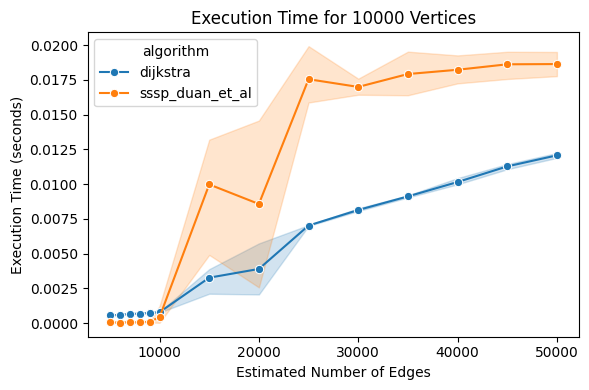

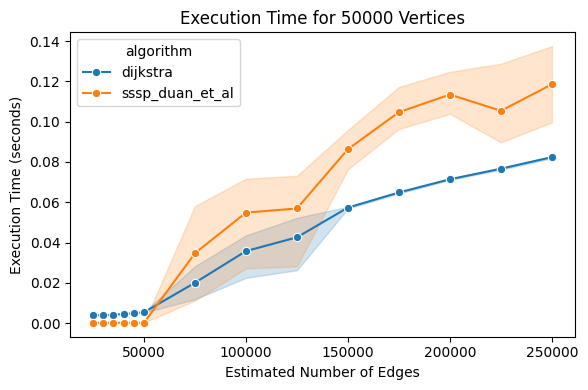

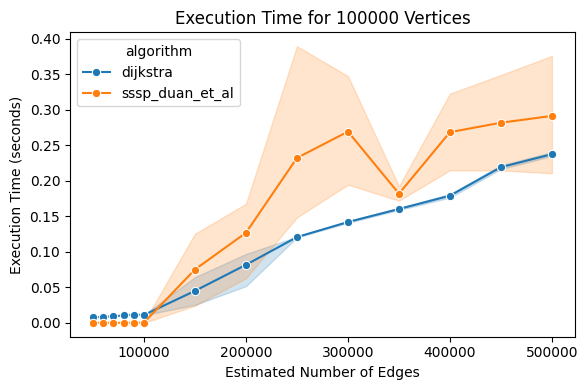

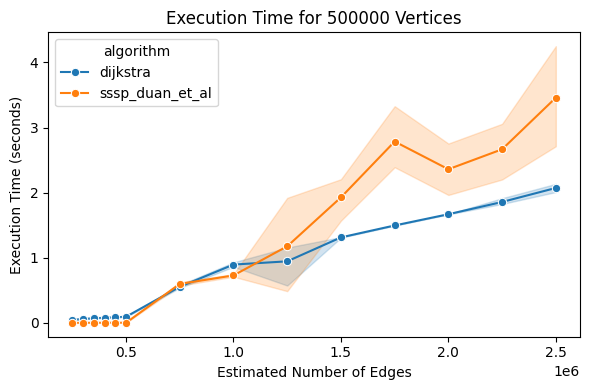

In [19]:
num_vertices = sorted(df['num_vertices'].unique())

df = df.copy()
df["graph_id"] = df["graph"].str.extract(r"i(\d+)").astype(int)

for num in num_vertices:

    subset = df[df['num_vertices'] == num]

    plt.figure(figsize=(6, 4))

    sns.lineplot(
        x='edge_estimate',
        y='execution_time',
        hue='algorithm',
        marker='o',
        data=subset
    )

    plt.title(f'Execution Time for {num} Vertices')
    plt.xlabel('Estimated Number of Edges')
    plt.ylabel('Execution Time (seconds)')

    plt.tight_layout()
    plt.show()

## Recomendações da IA

#### 1. Tempo x Grau Médio

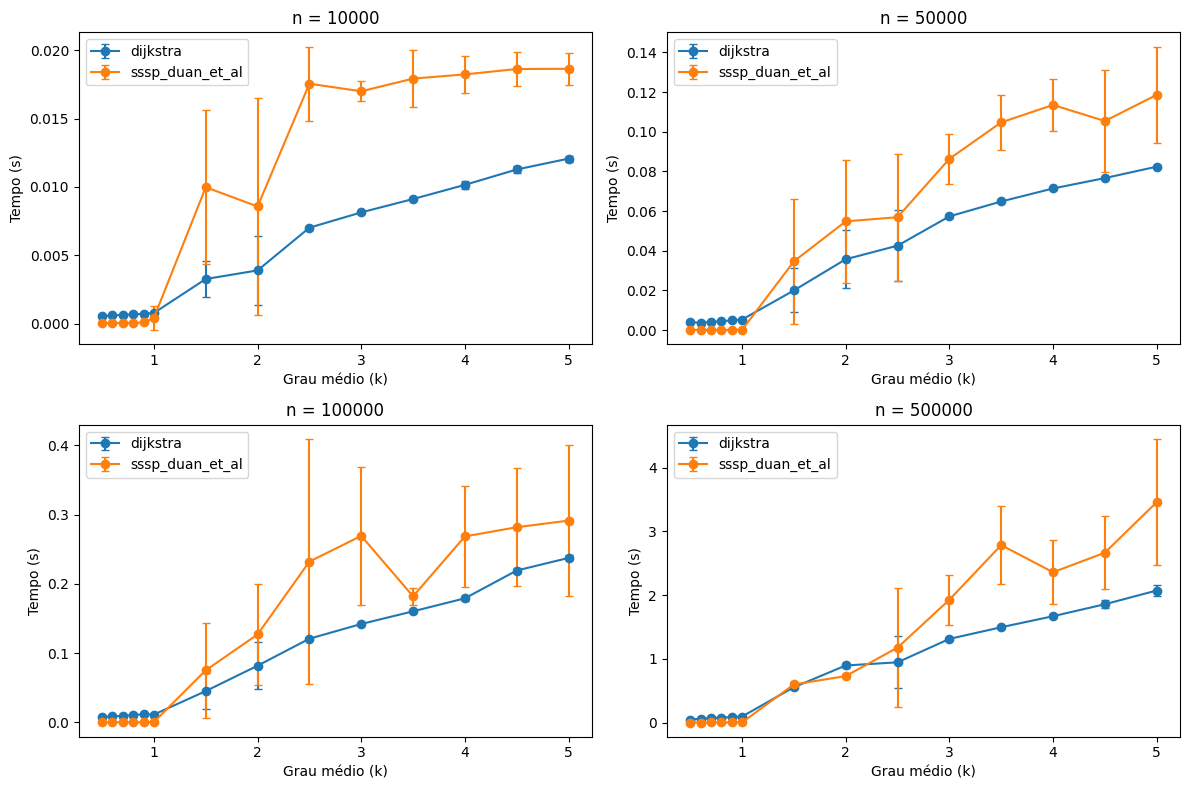

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/more_sparse.csv")

summary = (
    df.groupby(
        ["num_vertices", "avg_degree_k", "algorithm"]
    )["execution_time"]
    .agg(["mean", "std"])
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, n in zip(axes, sorted(df["num_vertices"].unique())):

    subset = summary[
        summary["num_vertices"] == n
    ]

    for alg in subset["algorithm"].unique():

        data = subset[
            subset["algorithm"] == alg
        ]

        ax.errorbar(
            data["avg_degree_k"],
            data["mean"],
            yerr=data["std"],
            marker="o",
            capsize=3,
            label=alg
        )

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Grau médio (k)")
    ax.set_ylabel("Tempo (s)")
    ax.legend()

plt.tight_layout()
plt.show()

#### 2. Tempo x Número de vértices

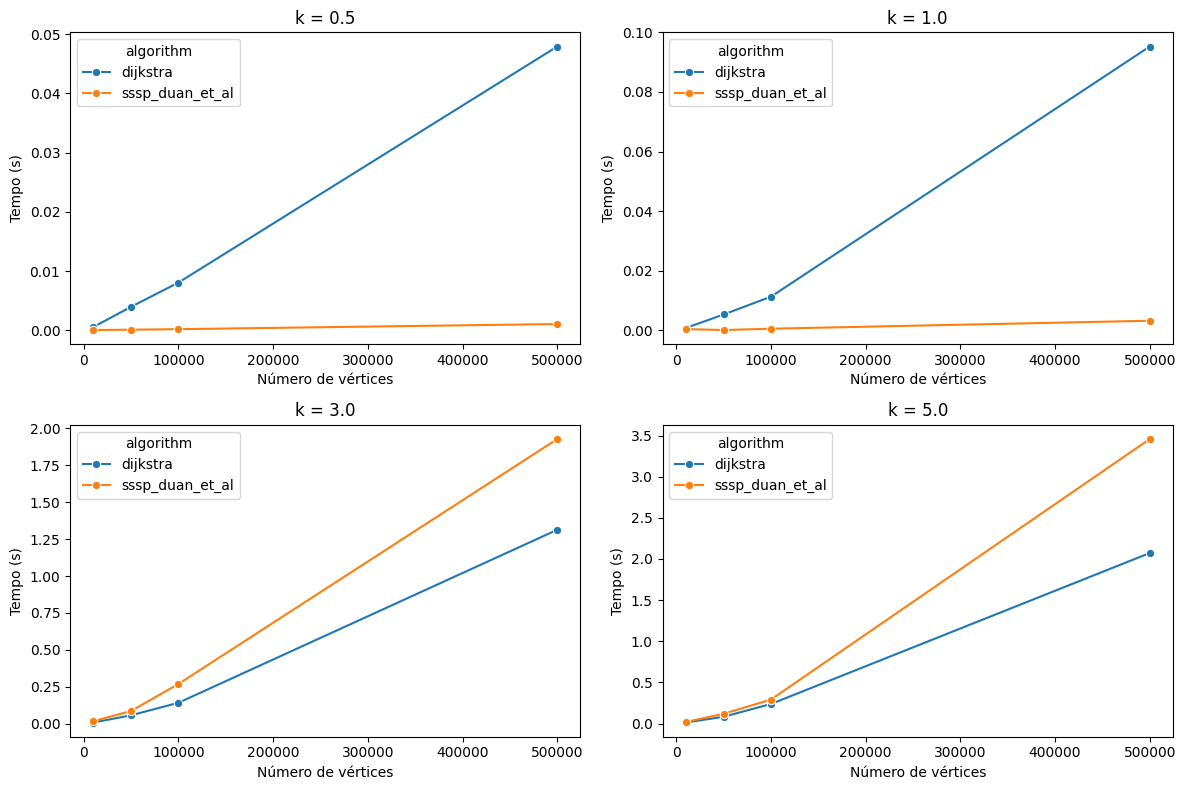

In [21]:
import numpy as np

summary = (
    df.groupby(
        ["num_vertices", "avg_degree_k", "algorithm"]
    )["execution_time"]
    .mean()
    .reset_index()
)

k_values = [0.5, 1.0, 3.0, 5.0]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, k in zip(axes, k_values):

    subset = summary[
        summary["avg_degree_k"] == k
    ]

    sns.lineplot(
        data=subset,
        x="num_vertices",
        y="execution_time",
        hue="algorithm",
        marker="o",
        ax=ax
    )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("Número de vértices")
    ax.set_ylabel("Tempo (s)")

plt.tight_layout()
plt.show()

#### 3. Speedup (D/BMSSP)

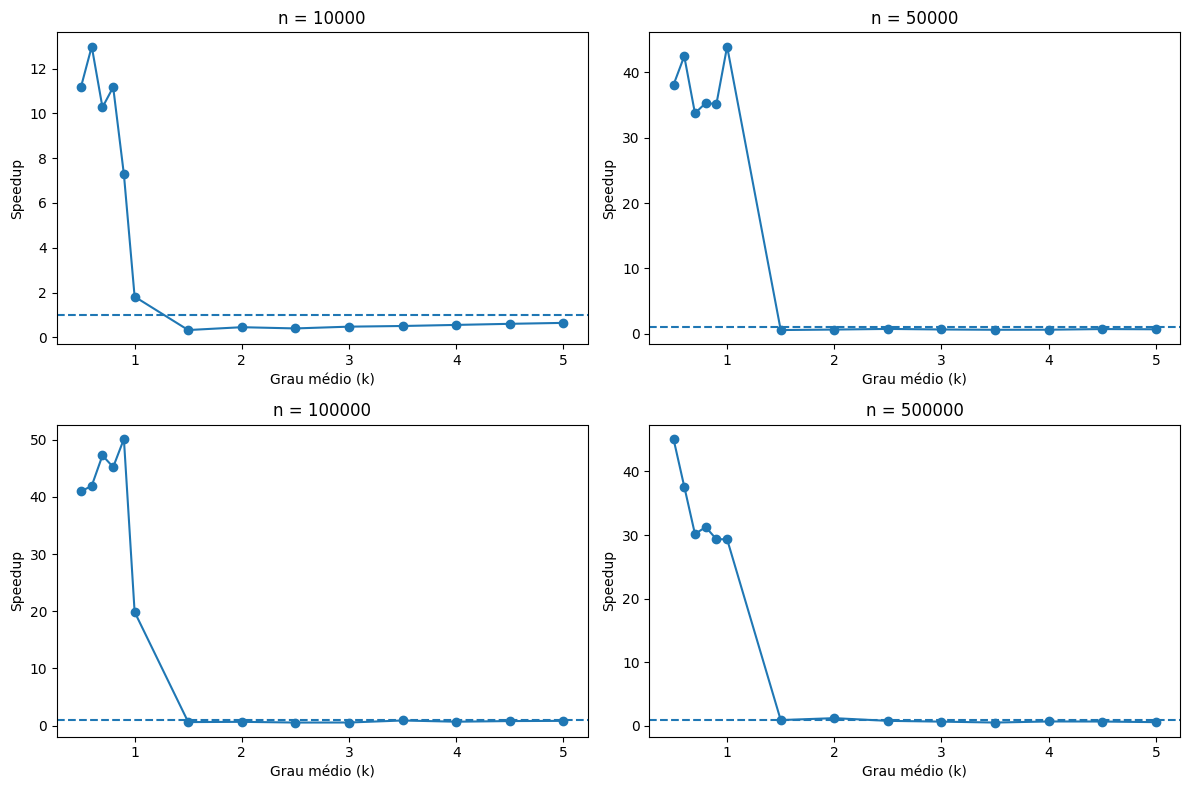

In [24]:
pivot = (
    df.groupby(
        ["num_vertices", "avg_degree_k", "algorithm"]
    )["execution_time"]
    .mean()
    .unstack()
    .reset_index()
)

pivot["speedup"] = (
    pivot["dijkstra"]
    /
    pivot["sssp_duan_et_al"]
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, n in zip(
    axes,
    sorted(pivot["num_vertices"].unique())
):

    subset = pivot[
        pivot["num_vertices"] == n
    ]

    ax.plot(
        subset["avg_degree_k"],
        subset["speedup"],
        marker="o"
    )

    ax.axhline(
        1,
        linestyle="--"
    )

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Grau médio (k)")
    ax.set_ylabel("Speedup")

plt.tight_layout()
plt.show()

In [25]:
best_speedups = (
    pivot.loc[
        pivot.groupby("num_vertices")["speedup"].idxmax()
    ][["num_vertices", "avg_degree_k", "speedup"]]
)

print(best_speedups)

algorithm  num_vertices  avg_degree_k    speedup
1                 10000           0.6  12.982809
19                50000           1.0  43.966067
32               100000           0.9  50.133386
42               500000           0.5  45.098365
